# Arbitrage in the MISO electricity markets

## 1. Setup

Install the packages used in the calculations and figures.

In [1]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


Import the downloader and the numerical, tabular and plotting interfaces.

In [2]:
from __future__ import annotations

from collections import deque
from collections.abc import Iterator
from datetime import date, timedelta
from math import erfc, sqrt
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.legend import Legend
from matplotlib.lines import Line2D

from src.download import MISO


Fix the sample periods, the smoothing window and the hub universe before examining returns.

In [3]:
DATA, FIGURES = Path("data"), Path("figures")
HISTORY_START, HISTORY_END = date(2008, 1, 1), date(2012, 12, 31)
EARLY_START = date(2005, 4, 1)
RECENT_START, RECENT_END = date(2024, 1, 1), date(2026, 8, 31)
PUBLICATION = date(2026, 9, 14)
WINDOW = 45
RECENT_WARMUP = RECENT_START - timedelta(days=WINDOW - 1)
HUBS = ("ARKANSAS.HUB", "ILLINOIS.HUB", "INDIANA.HUB", "LOUISIANA.HUB", "MICHIGAN.HUB", "MINN.HUB", "MS.HUB", "TEXAS.HUB")
EPOCH = pd.Timestamp("1970-01-01")
BLUE, ORANGE, GREEN = "#000099", "#C55018", "#007E66"
plt.rcParams.update(
    {
        "figure.figsize": (11, 4),
        "figure.dpi": 120,
        "font.size": 11,
        "axes.facecolor": "#EBEBEB",
        "axes.edgecolor": "#EBEBEB",
        "axes.grid": True,
        "grid.color": "white",
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "svg.fonttype": "none",
    }
)
pd.set_option("display.max_columns", 14)


## 2. Download Data and create DataFrames

Prices are hourly observations at published commercial nodes, in USD/MWh.
Each timestamp marks the start of an hour in fixed EST (UTC−05:00), including
summer dates. 

Historical DA reports contain LMP; RT prices are final hourly prices.

The extra 44 recent days initialize the 45-day moving average.

In [ ]:
price_paths: dict[str, tuple[Path, Path]] = {}
for sample, first, last in [("history", EARLY_START, HISTORY_END), ("recent", RECENT_WARMUP, RECENT_END)]:
    da_path = DATA / f"prices_day_ahead_{first:%Y%m%d}_{last:%Y%m%d}.parquet"
    rt_path = DATA / f"prices_real_time_{first:%Y%m%d}_{last:%Y%m%d}.parquet"
    if not da_path.exists():
        MISO.download_prices(first, last, "day_ahead", da_path)
    if not rt_path.exists():
        MISO.download_prices(first, last, "real_time", rt_path)
    price_paths[sample] = da_path, rt_path

with pq.ParquetFile(price_paths["history"][0]) as price_file:
    price_preview = price_file.read_row_group(0).to_pandas().head(8).copy()
price_preview


,timestamp,node,lmp_usd_mwh
0,2005-04-01 00:00:00-05:00,AEBN,19.94
1,2005-04-01 00:00:00-05:00,AEC,19.71
2,2005-04-01 00:00:00-05:00,AECI,19.27
3,2005-04-01 00:00:00-05:00,AEP,19.72
4,2005-04-01 00:00:00-05:00,ALTE.ALTE,19.87
5,2005-04-01 00:00:00-05:00,ALTE.BLACKH0K3,19.32
6,2005-04-01 00:00:00-05:00,ALTE.BLACKH0K4,19.32
7,2005-04-01 00:00:00-05:00,ALTE.CC.RIVSID,19.25


Daily cleared virtual volumes come from the public Day-Ahead Pricing report.
These are energy totals in MWh/day.

In [5]:
volume_path = DATA / "virtual_volumes_20080101_20121231.parquet"
if not volume_path.exists():
    MISO.download_virtual_volumes(HISTORY_START, HISTORY_END, volume_path)
volumes = pd.read_parquet(volume_path).set_index("date").sort_index()
if not volumes.index.equals(pd.date_range(HISTORY_START, HISTORY_END, freq="D")):
    raise ValueError("Virtual volumes must cover every requested date exactly once")
volumes.head()


,virtual_demand_mwh,virtual_supply_mwh
date,,
2008-01-01,125368.4,35549.3
2008-01-02,112963.3,56918.1
2008-01-03,141792.7,77349.3
2008-01-04,117245.7,80123.9
2008-01-05,135046.1,94724.1


**Cost specification: administrative fees.** We collect fees to calculate profit
after trading costs. Schedule 17 covers market operation, Schedule 24 covers
local balancing services, and a separate fee applies to each submitted hourly
bid. The table shows rate ranges: USD/MWh for the first two fees and USD/bid
for the third.


In [27]:
administration: dict[str, pd.DataFrame] = {}
for sample, first, last in [("history", EARLY_START, HISTORY_END), ("recent", RECENT_START, RECENT_END)]:
    path = DATA / f"administrative_rates_{first:%Y%m%d}_{last:%Y%m%d}.parquet"
    if not path.exists():
        MISO.download_administrative_rates(first, last, path)
    administration[sample] = pd.read_parquet(path).set_index("effective_date")

pd.concat(administration, names=["sample"]).groupby(level="sample").agg(["min", "max"])


schedule_17_usd_mwh         schedule_24_usd_mwh          \
                        min     max                 min     max   
sample                                                            
history              0.0430  0.1187              0.0000  0.0146   
recent               0.0526  0.1180              0.0122  0.0181   

        transaction_usd_bid       
                        min  max  
sample                            
history                 0.0  0.0  
recent                  0.0  0.0

**RSG rates.** RSG payments help cover generator costs not recovered through
market prices. We load DDC rates for virtual sales and CMC rates for network
constraints in the recent period. Reported zero DDC rates are retained; CMC
lists only nonzero rates. These revised rates are used to calculate realized
costs, not to predict them.


In [28]:
rsg_path = DATA / "rsg_rates_20240101_20260831.parquet"
if not rsg_path.exists():
    MISO.download_rsg_rates(RECENT_START, RECENT_END, rsg_path, publication=PUBLICATION)
rsg: pd.DataFrame = pd.read_parquet(rsg_path)

rsg.groupby("rate_type")["rate_usd_mwh"].describe().round(4)


,count,mean,std,min,25%,50%,75%,max
rate_type,,,,,,,,
cmc,5380.0,503.9266,6373.2268,0.0005,10.2385,32.5853,91.7768,245674.4667
ddc,23376.0,0.3474,3.2188,-0.2496,0.0000,0.0022,0.0409,95.1857


**Node coefficients (CCF).** The same CMC rate can lead to different costs at
different nodes. CCF coefficients determine the share charged to a purchase or
sale at each node and hour. We need them only for days with nonzero CMC rates
and read one day at a time.


In [29]:
ccf_path = DATA / "constraint_factors_20240101_20260831.parquet"
active_days = tuple(sorted(set(rsg.loc[rsg["rate_type"].eq("cmc"), "timestamp"].dt.date)))
if not ccf_path.exists():
    MISO.download_constraint_factors(RECENT_START, RECENT_END, ccf_path, operating_days=active_days)
ccf_file = pq.ParquetFile(ccf_path)
ccf_groups: dict[date, int] = {}
for group in range(ccf_file.num_row_groups):
    row_group = ccf_file.metadata.row_group(group)
    if row_group.num_rows == 0:
        continue
    statistics = row_group.column(0).statistics
    if statistics is None or statistics.min is None:
        raise ValueError("CCF row groups require timestamp statistics")
    ccf_groups[pd.Timestamp(statistics.min).date()] = group

pd.Series({"Days with CMC rates": len(active_days), "Stored CCF rows": ccf_file.metadata.num_rows}, name="Count")


Days with CMC rates        357
Stored CCF rows        6552982
Name: Count, dtype: int64

**Coverage.** Historical hourly RSG inputs are absent from the accessible MISO
archive. The related author's [replication package](https://www.openicpsr.org/openicpsr/project/134425/version/V1/view)
lists `RSG_DIST_RT.csv` and `IM_RSG.csv`, but their download requires ICPSR
authentication. Historical after-RSG profits therefore remain unidentified.

For the recent period, match rates and factors on the exact constraint name and
hour. Case is significant in the published identifiers. Unmatched rates remain
missing information, rather than zero charges.

In [7]:
ccf_keys: list[pd.DataFrame] = []
for group in range(ccf_file.num_row_groups):
    batch = ccf_file.read_row_group(group, columns=["timestamp", "constraint"]).to_pandas()
    ccf_keys.append(batch.drop_duplicates())
factor_keys = pd.concat(ccf_keys, ignore_index=True).drop_duplicates()
cmc_rates = rsg.loc[rsg["rate_type"].eq("cmc")].drop(columns="rate_type")
coverage = cmc_rates.merge(factor_keys, on=["timestamp", "constraint"], how="left", indicator=True)
missing_cmc = coverage.loc[coverage["_merge"].eq("left_only")].drop(columns="_merge")
del ccf_keys, factor_keys, coverage
missing_cmc.head(20)


,timestamp,constraint,rate_usd_mwh
4257,2026-01-17 01:00:00-05:00,MP2306_14L_TAP_14L_THIBBI11_1_1 +++ MP2306,5.212880
4259,2026-01-17 02:00:00-05:00,MP2306_14L_TAP_14L_THIBBI11_1_1 +++ MP2306,5.300492
4261,2026-01-17 03:00:00-05:00,MP2306_14L_TAP_14L_THIBBI11_1_1 +++ MP2306,5.278487
4263,2026-01-17 04:00:00-05:00,MP2306_14L_TAP_14L_THIBBI11_1_1 +++ MP2306,5.180768
4265,2026-01-17 05:00:00-05:00,MP2306_14L_TAP_14L_THIBBI11_1_1 +++ MP2306,5.149049
4267,2026-01-17 06:00:00-05:00,MP2306_14L_TAP_14L_THIBBI11_1_1 +++ MP2306,4.680954
4269,2026-01-17 07:00:00-05:00,MP2306_14L_TAP_14L_THIBBI11_1_1 +++ MP2306,4.698542
4272,2026-01-17 08:00:00-05:00,MP2306_14L_TAP_14L_THIBBI11_1_1 +++ MP2306,4.646471
4275,2026-01-17 09:00:00-05:00,MP2306_14L_TAP_14L_THIBBI11_1_1 +++ MP2306,4.689654
4278,2026-01-17 10:00:00-05:00,MP2306_14L_TAP_14L_THIBBI11_1_1 +++ MP2306,4.637930


FTR awards are purchased point-to-point obligations from round 1 of the 2024–2026
annual auctions. Both endpoints must be in the eight-hub universe. Retain only
delivery terms that intersect the sample; full-term valuation below requires
complete price coverage. DA marginal congestion prices (MCC) determine FTR
entitlements; total LMP differences also contain losses and are unsuitable.

In [8]:
ftr_path = DATA / "ftr_awards_20240101_20260831.parquet"
if not ftr_path.exists():
    MISO.download_ftr_awards(
        RECENT_START, RECENT_END, ftr_path, auctions=tuple(date(year, 4, 1) for year in (2024, 2025, 2026)), nodes=HUBS
    )
awards = pd.read_parquet(ftr_path)
mcc_path = DATA / "congestion_day_ahead_20240601_20260831.parquet"
if not mcc_path.exists():
    MISO.download_prices("2024-06-01", RECENT_END, "day_ahead", mcc_path, nodes=HUBS, component="MCC")
mcc = pd.read_parquet(mcc_path)
awards.head()


,ftr_id,participant,source,sink,start_date,end_date,class,mw,auction_price_usd_mw,auction_date,round
0,648244584,CORP,INDIANA.HUB,MINN.HUB,2024-12-01,2025-02-28,Peak,10.0,-3540.21,2024-04-01,1
1,648297464,CORP,INDIANA.HUB,MINN.HUB,2024-12-01,2025-02-28,Off-peak,15.0,-4894.85,2024-04-01,1
2,648280949,FRPT,INDIANA.HUB,MINN.HUB,2024-12-01,2025-02-28,Peak,25.0,-3540.21,2024-04-01,1
3,648280950,FRPT,INDIANA.HUB,MINN.HUB,2024-12-01,2025-02-28,Peak,30.0,-3540.21,2024-04-01,1
4,648482260,FRPT,INDIANA.HUB,MINN.HUB,2024-12-01,2025-02-28,Off-peak,25.0,-4894.85,2024-04-01,1


**Matching condition.** Every retained DA node-hour must have exactly one RT
observation. Prices are paired before subtraction; a difference of cross-node
medians would estimate a different quantity.

In [9]:
def paired_days(da_path: Path, rt_path: Path) -> Iterator[pd.DataFrame]:
    """Yield one complete day of paired nodal prices and DA-minus-RT premiums.

    :param da_path: Day-ahead Parquet with one row group per operating day.
    :param rt_path: Real-time Parquet with the same daily partitioning.
    :return: Daily dataframes with matched prices; incomplete calendars raise errors.
    """
    da_file, rt_file = pq.ParquetFile(da_path), pq.ParquetFile(rt_path)
    if da_file.num_row_groups != rt_file.num_row_groups:
        raise ValueError("DA and RT must cover the same number of days")
    previous: date | None = None
    for group in range(da_file.num_row_groups):
        da = da_file.read_row_group(group).to_pandas()
        rt = rt_file.read_row_group(group).to_pandas()
        frame = da.merge(rt, on=["timestamp", "node"], how="outer", suffixes=("_da", "_rt"), validate="one_to_one", indicator=True)
        if frame.isna().any().any() or not frame["_merge"].eq("both").all():
            raise ValueError("Unmatched DA/RT node-hours")
        frame.drop(columns="_merge", inplace=True)
        hours = pd.DatetimeIndex(frame["timestamp"].unique()).sort_values()
        day = hours[0].date()
        expected = pd.date_range(day, periods=24, freq="h", tz="Etc/GMT+5")
        if not hours.equals(expected) or (previous is not None and day - previous != timedelta(days=1)):
            raise ValueError("Prices must contain consecutive complete fixed-EST days")
        if not frame.groupby("node", observed=True).size().eq(24).all():
            raise ValueError("Every node must contain 24 observations per day")
        frame["premium_usd_mwh"] = frame["lmp_usd_mwh_da"] - frame["lmp_usd_mwh_rt"]
        previous = day
        yield frame


**Cost accounting.** Calculate supply and demand charges separately. Explicit
zero CCFs are omitted in storage. For a matched constraint, unreported node
entries are treated as zero under a sparse-matrix assumption. The match flag
checks constraint-hour coverage; it does not verify every unreported node
entry. Missing constraints are flagged at every affected hour.
The resulting series deducts observed charges only wherever coverage is incomplete.

In [10]:
def attach_charges(frame: pd.DataFrame, admin: float, use_rsg: bool) -> pd.DataFrame:
    """Attach unit-position charges and indicate whether every CMC rate matched.

    :param frame: One day of paired nodal prices.
    :param admin: Schedule 17 + Schedule 24 + one per-bid fee, for a 1 MWh bid.
    :param use_rsg: Whether the day has published DDC and CMC inputs.
    :return: Nodal prices with supply_fee, demand_fee and cmc_constraints_matched columns.
    """
    frame["supply_fee"], frame["demand_fee"] = admin, admin
    frame["cmc_constraints_matched"] = False
    if not use_rsg:
        return frame
    day = pd.Timestamp(frame["timestamp"].iloc[0]).date()
    first = pd.Timestamp(day, tz="Etc/GMT+5")
    daily_rates = rsg.loc[rsg["timestamp"].between(first, first + timedelta(days=1), inclusive="left")]
    ddc = daily_rates.loc[daily_rates["rate_type"].eq("ddc")].set_index("timestamp")["rate_usd_mwh"]
    frame["supply_fee"] += frame["timestamp"].map(ddc)
    if frame["supply_fee"].isna().any():
        raise ValueError(f"Missing DDC rates on {day}")
    frame["cmc_constraints_matched"] = ~frame["timestamp"].isin(missing_cmc["timestamp"])
    if day not in ccf_groups:
        return frame
    factors = ccf_file.read_row_group(ccf_groups[day]).to_pandas()
    factors = factors.merge(cmc_rates, on=["timestamp", "constraint"], validate="many_to_one")
    factors["cmc_supply"] = (-factors["factor"]).clip(lower=0) * factors["rate_usd_mwh"]
    factors["cmc_demand"] = factors["factor"].clip(lower=0) * factors["rate_usd_mwh"]
    charges = factors.groupby(["timestamp", "node"], observed=True)[["cmc_supply", "cmc_demand"]].sum()
    frame = frame.join(charges, on=["timestamp", "node"], validate="one_to_one")
    frame["supply_fee"] += frame["cmc_supply"].fillna(0)
    frame["demand_fee"] += frame["cmc_demand"].fillna(0)
    frame.drop(columns=["cmc_supply", "cmc_demand"], inplace=True)
    return frame


**Trading specification.** A supply position earns $P^{DA}-P^{RT}$; a demand
position earns its negative. The benchmark sells 1 MWh at every node-hour.
A second rule trades the sign of the same node-hour premium two days earlier,
and abstains when that lag is unavailable. No contemporaneous price selects a
position. The lagged rule is a diagnostic using final revised prices: an
executable backtest would also require the prices available before each bid deadline.

Both rules assume acceptance of every order, no price impact and no capital
limit. Published nodes form the universe, without filtering for virtual bidding
eligibility. These are hypothetical price-taking portfolios, not riskless trades.
Daily batches also supply sufficient statistics for the descriptive tables.

In [11]:
def summarize_prices(sample: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Reduce daily nodal batches to hourly returns, price moments and hub data.

    :param sample: "history" or "recent", selecting prices and administrative rates.
    :return: Hourly portfolio observations, daily price moments and recent hub prices.
        Only two prior daily premium vectors are retained for the lagged strategy.
    """
    hourly_parts: list[pd.DataFrame] = []
    moment_rows: list[dict[str, str | date | int | float]] = []
    hub_parts: list[pd.DataFrame] = []
    past: deque[pd.Series[float]] = deque(maxlen=2)
    rates = administration[sample]
    for frame in paired_days(*price_paths[sample]):
        day = pd.Timestamp(frame["timestamp"].iloc[0]).date()
        index = pd.MultiIndex.from_frame(frame[["timestamp", "node"]])
        lag = past.popleft() if len(past) == 2 else pd.Series(dtype=float)
        frame["lag_position"] = np.sign(lag.reindex(index).fillna(0).to_numpy(dtype=float))
        premium = frame.set_index(["timestamp", "node"])["premium_usd_mwh"].copy()
        premium.index = pd.MultiIndex.from_arrays([frame["timestamp"] + timedelta(days=2), frame["node"]])
        past.append(premium)
        applicable = rates.loc[rates.index <= pd.Timestamp(day)].tail(1)
        admin = float(applicable.sum(axis=1).iloc[0]) if not applicable.empty else float("nan")
        frame = attach_charges(frame, admin, sample == "recent" and day >= RECENT_START)
        frame["lag_gross_usd"] = frame["lag_position"] * frame["premium_usd_mwh"]
        frame["lag_mwh"] = frame["lag_position"].abs()
        frame["lag_fee_usd"] = np.where(
            frame["lag_position"].gt(0), frame["supply_fee"], np.where(frame["lag_position"].lt(0), frame["demand_fee"], 0)
        )
        groups = frame.groupby("timestamp", observed=True)
        hourly = groups.agg(
            nodes=("node", "size"),
            mean_premium=("premium_usd_mwh", "mean"),
            median_premium=("premium_usd_mwh", "median"),
            sell_gross_usd=("premium_usd_mwh", "sum"),
            lag_gross_usd=("lag_gross_usd", "sum"),
            lag_mwh=("lag_mwh", "sum"),
            cmc_constraints_matched=("cmc_constraints_matched", "all"),
        )
        hourly = hourly.join(groups[["supply_fee", "lag_fee_usd"]].sum(min_count=1))
        hourly_parts.append(hourly)
        for market, column in [("DA", "lmp_usd_mwh_da"), ("RT", "lmp_usd_mwh_rt")]:
            values = frame[column].to_numpy(dtype=float)
            moment_rows.append(
                {
                    "date": day,
                    "market": market,
                    "N": len(values),
                    "sum": float(values.sum()),
                    "sum_squares": float(np.square(values).sum()),
                    "Min": float(values.min()),
                    "Max": float(values.max()),
                }
            )
        if sample == "recent" and day >= RECENT_START:
            hub_parts.append(
                frame.loc[
                    frame["node"].isin(HUBS),
                    ["timestamp", "node", "premium_usd_mwh", "supply_fee", "demand_fee", "cmc_constraints_matched"],
                ]
            )
    hubs = pd.concat(hub_parts, ignore_index=True) if hub_parts else pd.DataFrame()
    return pd.concat(hourly_parts), pd.DataFrame(moment_rows), hubs


history, history_moments, _ = summarize_prices("history")
recent, recent_moments, hub_prices = summarize_prices("recent")
history.loc["2010-01-01"].head()


,nodes,mean_premium,median_premium,sell_gross_usd,lag_gross_usd,lag_mwh,cmc_constraints_matched,supply_fee,lag_fee_usd
timestamp,,,,,,,,,
2010-01-01 00:00:00-05:00,1916,2.346284,2.04,4495.48,-6703.16,1912.0,False,178.3796,178.0072
2010-01-01 01:00:00-05:00,1916,-0.988434,-0.40,-1893.84,196.91,1907.0,False,178.3796,177.5417
2010-01-01 02:00:00-05:00,1916,-1.237443,-0.78,-2370.94,-1491.18,1912.0,False,178.3796,178.0072
2010-01-01 03:00:00-05:00,1916,-1.766456,-1.21,-3384.53,-1597.86,1912.0,False,178.3796,178.0072
2010-01-01 04:00:00-05:00,1916,-11.776681,-11.17,-22564.12,-6643.34,1912.0,False,178.3796,178.0072


**Descriptive evidence, Table 1.** Compare the two price distributions using
N, Mean, Std, Min and Max. The historical price sample is 2010–2012, matching
the period discussed with the paper's trading exercises. No quantiles or full
nodal copies are needed for these five statistics.

In [12]:
def describe_moments(moments: pd.DataFrame, start: date, end: date) -> pd.DataFrame:
    """Combine daily counts and moments into exact sample summary statistics.

    :param moments: Daily N, sum, sum_squares, Min and Max for each price market.
    :param start: First included operating date.
    :param end: Last included operating date.
    :return: DA and RT rows with N, Mean, sample Std, Min and Max.
    """
    selected = moments.loc[moments["date"].between(start, end)]
    result = selected.groupby("market").agg({"N": "sum", "sum": "sum", "sum_squares": "sum", "Min": "min", "Max": "max"})
    result["Mean"] = result["sum"] / result["N"]
    result["Std"] = np.sqrt((result["sum_squares"] - result["sum"] ** 2 / result["N"]) / (result["N"] - 1))
    return result[["N", "Mean", "Std", "Min", "Max"]]


price_description = pd.concat(
    {
        "2010–2012": describe_moments(history_moments, date(2010, 1, 1), HISTORY_END),
        "2024–2026": describe_moments(recent_moments, RECENT_START, RECENT_END),
    },
    names=["Sample", "Market"],
)
price_description.round(2)


N   Mean    Std      Min      Max
Sample    Market                                          
2010–2012 DA      48547536  29.85  14.42  -977.11   756.85
          RT      48547536  29.16  27.04 -1317.75  3225.17
2024–2026 DA      58428048  35.68  36.41 -1399.42  2039.82
          RT      58428048  34.45  56.54 -3596.76  4686.20

## 3. Day-ahead premium — Fig. 1 and Table 2

**$H_0:\beta_y=0$; $H_1:\beta_y\ne0$.** Regress the hourly cross-node premium
on year indicators, without an intercept, as in Table 2. Show both the mean and
median definitions. Bartlett-weighted Newey–West standard errors use 168 hourly
lags (one week); the paper does not specify its bandwidth. The two-sided
p-values use the large-sample normal approximation. Coefficients can be compared
directly; equality of the reported standard errors is not implied.

In [13]:
def hac_ols(y: pd.Series[float], x: pd.DataFrame, lags: int) -> pd.DataFrame:
    """Fit OLS with a Bartlett Newey-West covariance and two-sided normal p-values.

    :param y: Dependent variable in chronological, equally spaced order.
    :param x: Full-rank regressors with the same index; include an intercept explicitly.
    :param lags: Maximum autocovariance lag; 0 gives the uncorrected HC0 covariance.
    :return: Coefficients, HAC standard errors, z-statistics, p-values and sample size.
    """
    if not y.index.equals(x.index) or not 0 <= lags < len(y):
        raise ValueError("Aligned observations and 0 <= lags < N are required")
    target, design = y.to_numpy(dtype=float), x.to_numpy(dtype=float)
    if not np.isfinite(target).all() or not np.isfinite(design).all():
        raise ValueError("Regression inputs must be finite")
    beta, _, rank, _ = np.linalg.lstsq(design, target, rcond=None)
    if rank != design.shape[1] or len(target) <= rank:
        raise ValueError("Regressors must have full rank and residual degrees of freedom")
    residuals = target - design @ beta
    scores = design * residuals[:, None]
    meat = scores.T @ scores
    for lag in range(1, lags + 1):
        cross = scores[lag:].T @ scores[:-lag]
        meat += (1 - lag / (lags + 1)) * (cross + cross.T)
    bread = np.linalg.inv(design.T @ design)
    standard_error = np.sqrt(np.maximum(np.diag(bread @ meat @ bread), 0))
    if (standard_error == 0).any():
        raise ValueError("Zero sampling variance prevents normal inference")
    z_stat = beta / standard_error
    return pd.DataFrame(
        {
            "Coefficient": beta,
            "HAC SE": standard_error,
            "z": z_stat,
            "p-value": [erfc(abs(float(value)) / sqrt(2)) for value in z_stat],
            "N": len(y),
        },
        index=x.columns,
    )


regression_sample = history.loc["2008":"2012"]
year_dummies = pd.get_dummies(pd.DatetimeIndex(regression_sample.index).year).astype(float)
year_dummies.index = regression_sample.index
table_2 = pd.concat(
    {
        measure: hac_ols(regression_sample[column], year_dummies, lags=168)
        for measure, column in [("Mean", "mean_premium"), ("Median", "median_premium")]
    },
    names=["Aggregation", "Year"],
)
table_2["Paper coefficient"] = [1.38, 0.86, 1.14, 0.52, 0.39, 1.54, 1.14, 1.42, 1.13, 0.83]
table_2.round(4)


Coefficient  HAC SE       z  p-value      N  \
Aggregation Year                                                
Mean        2008       1.3832  0.6525  2.1199   0.0340  43848   
            2009       0.8580  0.3286  2.6112   0.0090  43848   
            2010       1.1406  0.3329  3.4263   0.0006  43848   
            2011       0.5234  0.4253  1.2307   0.2184  43848   
            2012       0.3926  0.4112  0.9548   0.3397  43848   
Median      2008       1.5375  0.6553  2.3463   0.0190  43848   
            2009       1.1441  0.3167  3.6124   0.0003  43848   
            2010       1.4249  0.3359  4.2425   0.0000  43848   
            2011       1.1295  0.3815  2.9606   0.0031  43848   
            2012       0.8318  0.4064  2.0469   0.0407  43848   

                  Paper coefficient  
Aggregation Year                     
Mean        2008               1.38  
            2009               0.86  
            2010               1.14  
            2011               0.52  
            2012               0.39  
Median      2008               1.54  
            2009               1.14  
            2010               1.42  
            2011               1.13  
            2012               0.83

**Figure specification.** Plot the trailing mean of 45 daily means of the
hourly cross-node median premium. This explicit estimator agrees with the
median coefficients of Table 2. Fig. 1 does not identify its cross-node
aggregation, and its printed curve is not numerically identical to this
reconstruction. No rescaling is used to force visual agreement.

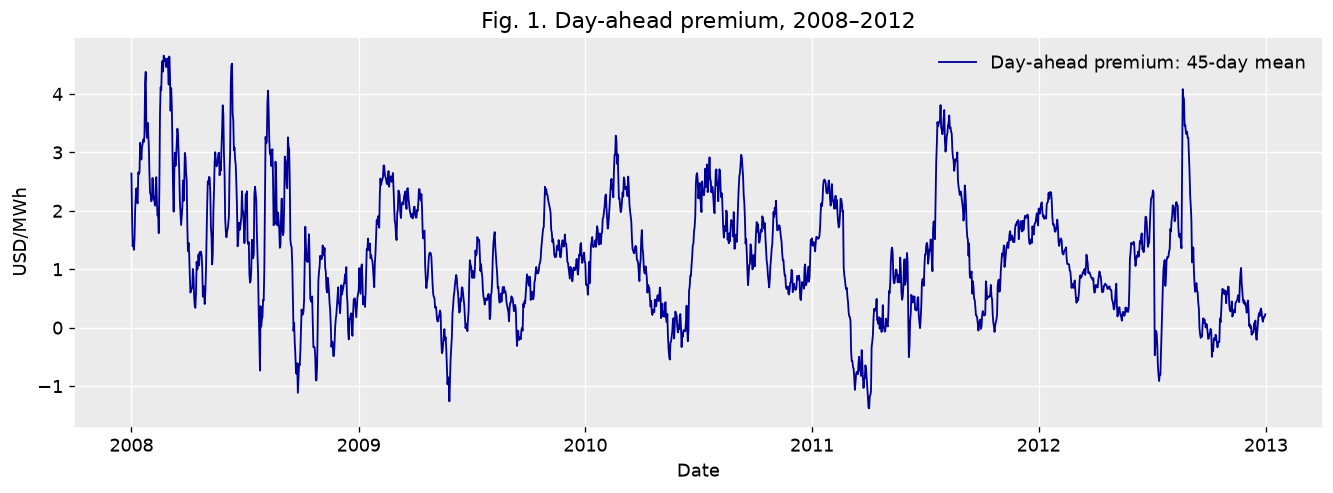

In [14]:
def line_chart(
    frame: pd.DataFrame, labels: dict[str, str], title: str, ylabel: str, *, dashed: tuple[str, ...] = (), steps: tuple[str, ...] = ()
) -> tuple[Figure, Axes]:
    """Draw dated series with common publication styling and no area shading.

    :param frame: Numeric columns indexed by date or timestamp.
    :param labels: Ordered mapping of column names to legend labels.
    :param title: Figure title in English.
    :param ylabel: Vertical axis label, including units.
    :param dashed: Columns to draw with dashed lines.
    :param steps: Columns to hold constant until the next date.
    :return: Figure and axes, available for further annotation or export.
    """
    fig, ax = plt.subplots(layout="constrained")
    dates = pd.DatetimeIndex(frame.index).tz_localize(None)
    positions = (dates - EPOCH).days.to_numpy(dtype=float)
    for number, (column, label) in enumerate(labels.items()):
        color = (BLUE, ORANGE, GREEN, "#555555")[number % 4]
        ax.add_line(
            Line2D(
                positions,
                frame[column].to_numpy(dtype=float),
                color=color,
                linewidth=1.1,
                linestyle="--" if column in dashed else "-",
                drawstyle="steps-post" if column in steps else "default",
                label=label,
            )
        )
    ax.autoscale_view()
    ax.title.set_text(title)
    ax.yaxis.label.set_text(ylabel)
    ax.xaxis.label.set_text("Date")
    locator = mdates.AutoDateLocator(minticks=5, maxticks=9)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    handles = list(ax.lines)
    ax.add_artist(Legend(ax, handles, list(labels.values()), loc="best", frameon=False))
    return fig, ax


historical_daily = history[["median_premium", "mean_premium"]].resample("D").mean()
historical_daily["premium_45d"] = historical_daily["median_premium"].rolling(WINDOW).mean()
fig, ax = line_chart(
    historical_daily.loc["2008":"2012"],
    {"premium_45d": "Day-ahead premium: 45-day mean"},
    "Fig. 1. Day-ahead premium, 2008–2012",
    "USD/MWh",
)
fig.savefig(FIGURES / "fig_1_day_ahead_premium_2008_2012.svg")


**Recent extension.** Compare the same premium estimator with the annual
volume-weighted mean charge for the all-node supply portfolio. The dashed line
includes administrative charges, DDC and matched CMC. It is an ex-post annual
benchmark, not a fee known before a trade. The 2026 value excludes the unobserved
CMC component in 15 hours on 17 January; it is a lower bound on that cost measure.

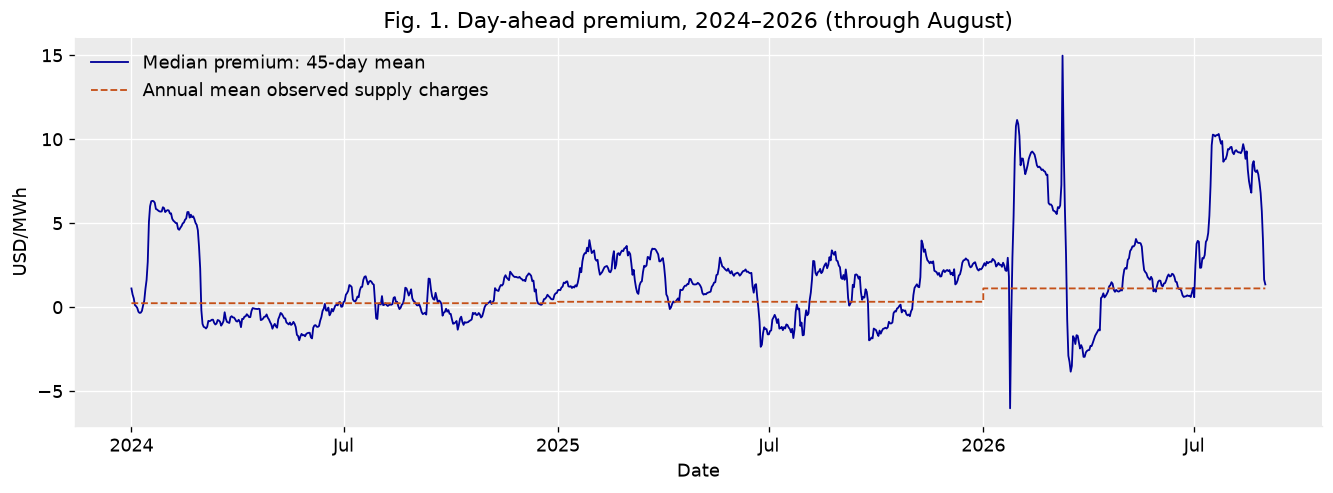

In [15]:
recent_sample = recent.loc["2024":].copy()
recent_daily = recent_sample.resample("D").agg(
    {
        "mean_premium": "mean",
        "median_premium": "mean",
        "nodes": "sum",
        "sell_gross_usd": "sum",
        "supply_fee": "sum",
        "cmc_constraints_matched": "all",
    }
)
recent_daily["premium_45d"] = recent["median_premium"].resample("D").mean().rolling(WINDOW).mean()
annual_cost = recent_sample.groupby(pd.DatetimeIndex(recent_sample.index).year)[["supply_fee", "nodes"]].sum()
annual_cost["observed_usd_mwh"] = annual_cost["supply_fee"] / annual_cost["nodes"]
recent_daily["annual_supply_cost"] = pd.DatetimeIndex(recent_daily.index).year.map(annual_cost["observed_usd_mwh"].to_dict())
fig, ax = line_chart(
    recent_daily,
    {"premium_45d": "Median premium: 45-day mean", "annual_supply_cost": "Annual mean observed supply charges"},
    "Fig. 1. Day-ahead premium, 2024–2026 (through August)",
    "USD/MWh",
    dashed=("annual_supply_cost",),
    steps=("annual_supply_cost",),
)
fig.savefig(FIGURES / "fig_1_day_ahead_premium_2024_2026.svg")


**$H_0:E[p_{nh}-c^S_{nh}]\le0$; $H_1:E[p_{nh}-c^S_{nh}]>0$.** Weekly
portfolio accounting uses the sum of nodal profits and costs, rather than a
median multiplied by the number of nodes. A positive realized week does not
establish predictability. Complete Monday–Sunday weeks are shown; missing CMC
coverage is carried into the result.

In [16]:
recent_daily["profit_after_observed_charges_usd"] = recent_daily["sell_gross_usd"] - recent_daily["supply_fee"]
weeks = recent_daily.resample("W-SUN")
recent_weeks = weeks[["nodes", "sell_gross_usd", "supply_fee", "profit_after_observed_charges_usd"]].sum()
recent_weeks["cmc_constraints_matched"] = weeks["cmc_constraints_matched"].all()
recent_weeks = recent_weeks.loc[weeks.size().eq(7)]
recent_weeks["observed_charge_usd_mwh"] = recent_weeks["supply_fee"] / recent_weeks["nodes"]
recent_weeks["profit_usd_mwh"] = recent_weeks["profit_after_observed_charges_usd"] / recent_weeks["nodes"]
recent_weeks.tail(8).round(3)


,nodes,sell_gross_usd,supply_fee,profit_after_observed_charges_usd,cmc_constraints_matched,observed_charge_usd_mwh,profit_usd_mwh
timestamp,,,,,,,
2026-07-12 00:00:00-05:00,438816,-359794.10,244109.580,-6.039037e+05,True,0.556,-1.376
2026-07-19 00:00:00-05:00,438816,16322089.13,445163.675,1.587693e+07,True,1.014,36.181
2026-07-26 00:00:00-05:00,438816,-2184513.15,85546.057,-2.270059e+06,True,0.195,-5.173
2026-08-02 00:00:00-05:00,438816,1281469.10,114749.614,1.166719e+06,True,0.261,2.659
2026-08-09 00:00:00-05:00,438816,225115.23,103841.547,1.212737e+05,True,0.237,0.276
2026-08-16 00:00:00-05:00,438816,207254.12,224797.543,-1.754342e+04,True,0.512,-0.040
2026-08-23 00:00:00-05:00,438816,267735.86,90374.258,1.773616e+05,True,0.206,0.404
2026-08-30 00:00:00-05:00,438816,751792.94,121843.921,6.299490e+05,True,0.278,1.436


## 4. Virtual demand and supply — Fig. 2

**$H_0:E[VD_d-VS_d]\le0$; $H_1:E[VD_d-VS_d]>0$.** A positive premium
rewards virtual supply, yet the paper reports more virtual demand. Weekly
points are mean daily cleared MWh, retaining complete Monday–Sunday weeks.

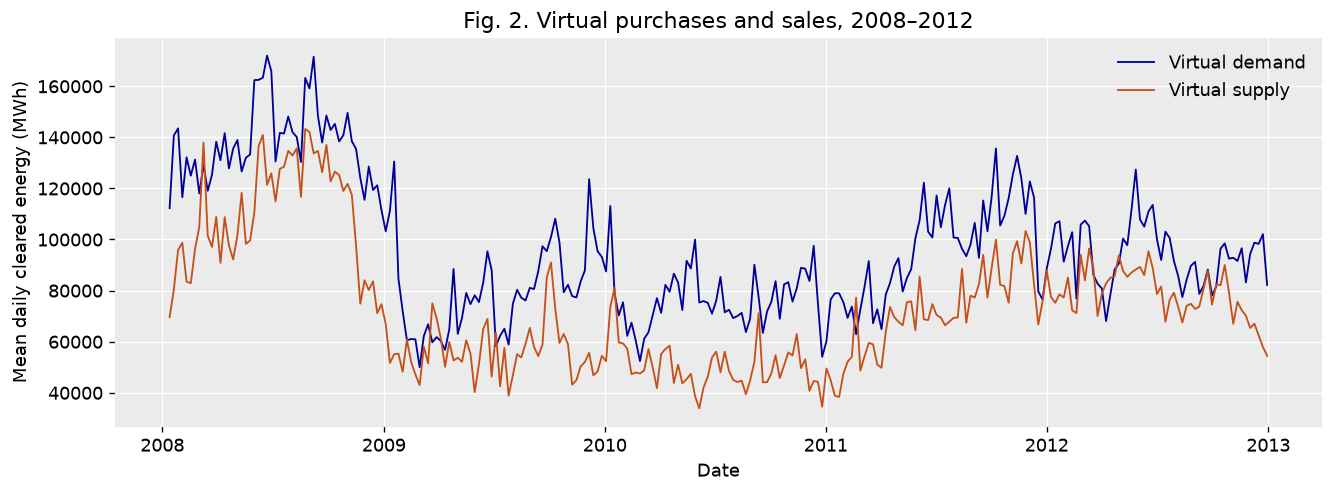

In [17]:
volume_weeks = volumes.resample("W-SUN")
weekly_volumes = volume_weeks.mean().loc[volume_weeks.size().eq(7)]
fig, ax = line_chart(
    weekly_volumes,
    {"virtual_demand_mwh": "Virtual demand", "virtual_supply_mwh": "Virtual supply"},
    "Fig. 2. Virtual purchases and sales, 2008–2012",
    "Mean daily cleared energy (MWh)",
)
fig.savefig(FIGURES / "fig_2_virtual_purchases_sales_2008_2012.svg")


Estimate the average daily demand-minus-supply imbalance with a 7-day HAC
bandwidth. The reported one-sided p-value tests the preceding hypothesis.

In [18]:
volume_gap = volumes["virtual_demand_mwh"] - volumes["virtual_supply_mwh"]
imbalance_test = hac_ols(volume_gap, pd.DataFrame({"Demand minus supply": 1.0}, index=volumes.index), lags=7)
imbalance_test["p-value: H1 > 0"] = [erfc(float(value) / sqrt(2)) / 2 for value in imbalance_test["z"]]
imbalance_test.drop(columns="p-value").round(4)


,Coefficient,HAC SE,z,N,p-value: H1 > 0
Demand minus supply,23704.3427,967.2915,24.5059,1827,0.0


## 5. Trading profits — Fig. 3 and Fig. 12

**$H_0:E[\pi_d]\le0$; $H_1:E[\pi_d]>0$.** The benchmark sells 1 MWh
at every published node in every hour:
$$
G_d=\sum_{h\in d}\sum_n(P^{DA}_{nh}-P^{RT}_{nh}),\qquad
\Pi_d=G_d-\sum_{h\in d}\sum_n c^S_{nh}.
$$

The historical panel shows gross profits and sensitivity to **assumed total
charges** of $0.20 and $0.30/MWh. These assumptions are not historical RSG
observations: Table 1 reports a mean pre-April-2011 RSG rate of $1.80/MWh.
Consequently this panel does not reproduce the after-RSG curve of Fig. 3.
The paper reports $7,604,298 after RSG for April 2011–December 2012, which
cannot be independently checked without those hourly inputs.

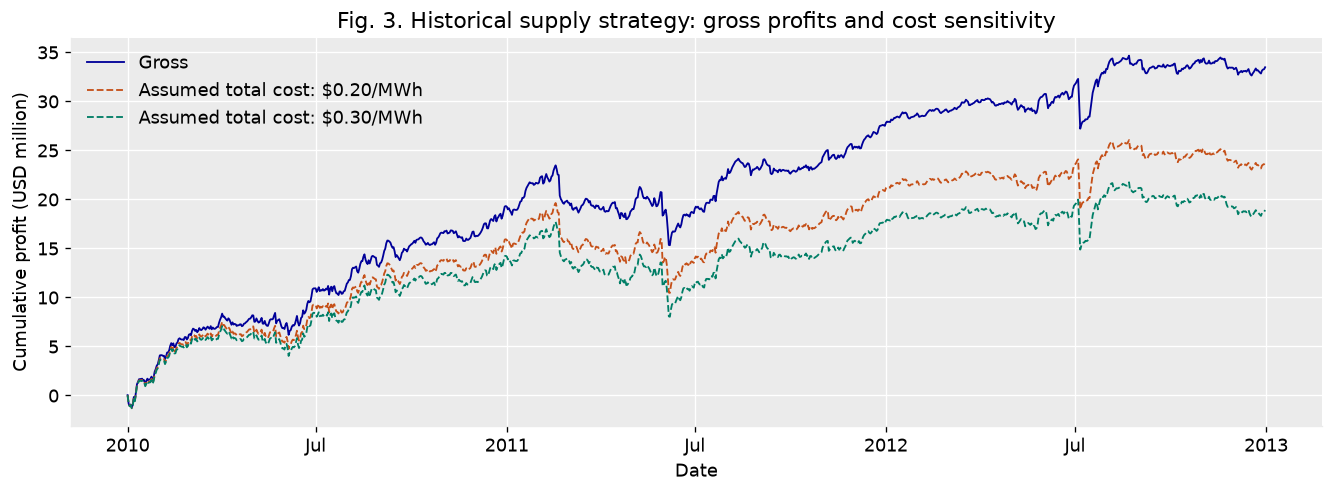

In [19]:
historical_trades = history.loc["2010":"2012"].resample("D").sum(numeric_only=True)
historical_sensitivity = (
    pd.DataFrame(
        {
            "gross": historical_trades["sell_gross_usd"],
            "cost_020": historical_trades["sell_gross_usd"] - 0.20 * historical_trades["nodes"],
            "cost_030": historical_trades["sell_gross_usd"] - 0.30 * historical_trades["nodes"],
        }
    ).cumsum()
    / 1_000_000
)
fig, ax = line_chart(
    historical_sensitivity,
    {"gross": "Gross", "cost_020": "Assumed total cost: $0.20/MWh", "cost_030": "Assumed total cost: $0.30/MWh"},
    "Fig. 3. Historical supply strategy: gross profits and cost sensitivity",
    "Cumulative profit (USD million)",
    dashed=("cost_020", "cost_030"),
)
fig.savefig(FIGURES / "fig_3_supply_strategy_2010_2012.svg")


**Recent extension.** Deduct observed administrative and RSG charges from the
same supply portfolio. All published CMC constraint-hours match in 2024–2025. From the missing
15 constraint-hours in January 2026 onward, cumulative profits after observed
charges are an upper bound under this nodal cost model, not fully identified
after-charge profits. The lagged rule uses the same cost accounting.

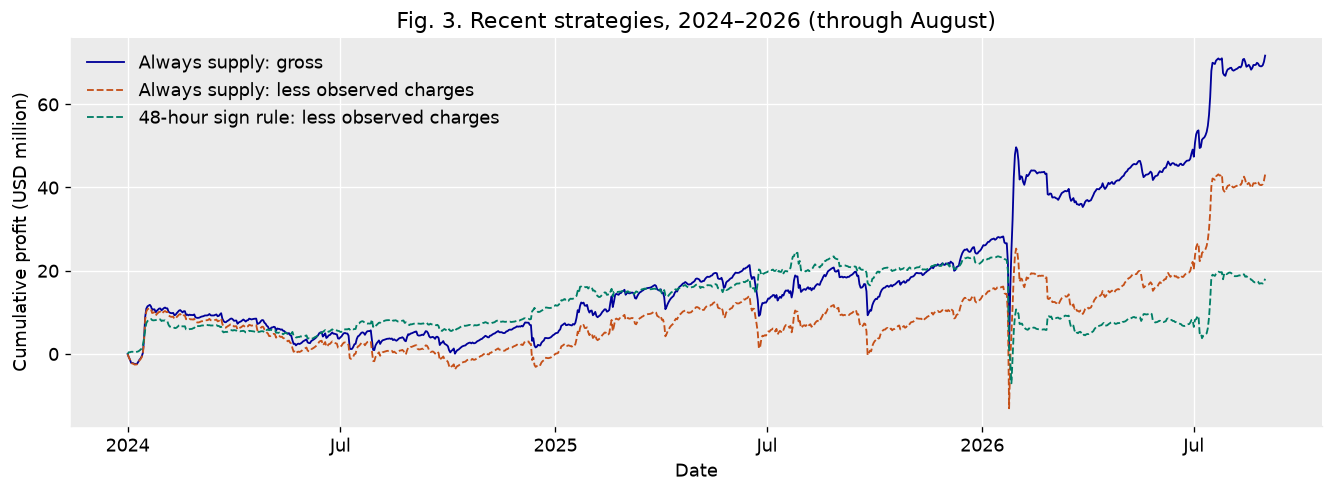

In [20]:
recent_sample["sell_after_observed_usd"] = recent_sample["sell_gross_usd"] - recent_sample["supply_fee"]
recent_sample["lag_after_observed_usd"] = recent_sample["lag_gross_usd"] - recent_sample["lag_fee_usd"]
recent_trades = recent_sample.resample("D").sum(numeric_only=True)
recent_cumulative = recent_trades[["sell_gross_usd", "sell_after_observed_usd", "lag_after_observed_usd"]].cumsum() / 1_000_000
fig, ax = line_chart(
    recent_cumulative,
    {
        "sell_gross_usd": "Always supply: gross",
        "sell_after_observed_usd": "Always supply: less observed charges",
        "lag_after_observed_usd": "48-hour sign rule: less observed charges",
    },
    "Fig. 3. Recent strategies, 2024–2026 (through August)",
    "Cumulative profit (USD million)",
    dashed=("sell_after_observed_usd", "lag_after_observed_usd"),
)
fig.savefig(FIGURES / "fig_3_strategies_2024_2026.svg")


**Long-run comparison, Fig. 12.** Extend the all-node supply calculation to the
market opening in April 2005. Actual portfolio dollars and daily cross-node
mean premium have different units. The paper's Fig. 12 has a dollar scale
inconsistent with its all-node portfolio caption; this extension uses explicit
portfolio dollars. Historical RSG, including retroactive settlements discussed
in Appendix B, is unobserved. The curves remain gross and assumed-cost scenarios.

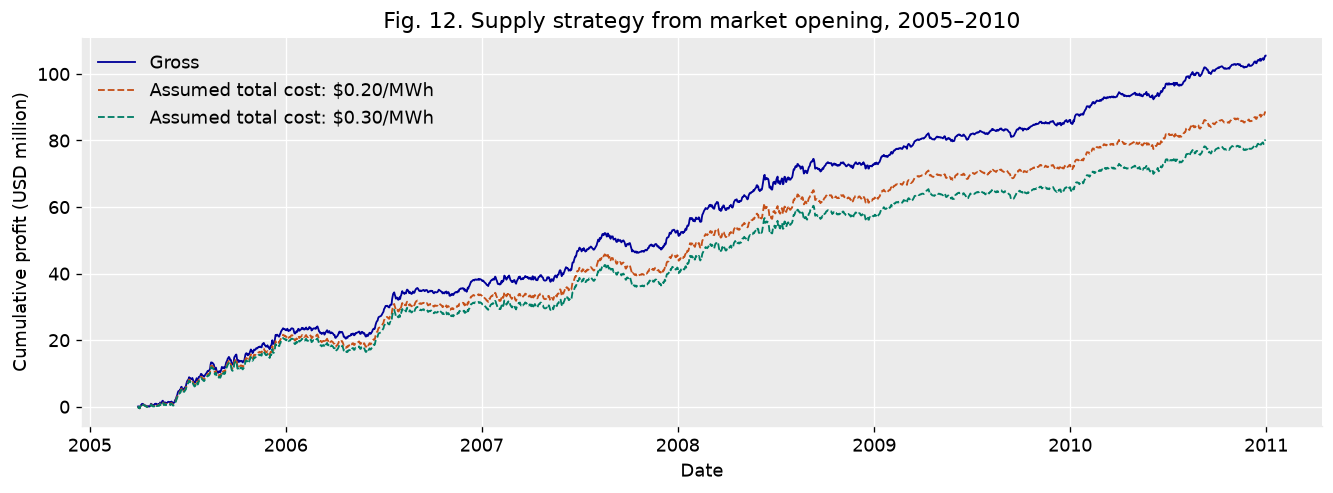

In [21]:
early_trades = history.loc["2005":"2010"].resample("D").sum(numeric_only=True)
early_sensitivity = (
    pd.DataFrame(
        {
            "gross": early_trades["sell_gross_usd"],
            "cost_020": early_trades["sell_gross_usd"] - 0.20 * early_trades["nodes"],
            "cost_030": early_trades["sell_gross_usd"] - 0.30 * early_trades["nodes"],
        }
    ).cumsum()
    / 1_000_000
)
fig, ax = line_chart(
    early_sensitivity,
    {"gross": "Gross", "cost_020": "Assumed total cost: $0.20/MWh", "cost_030": "Assumed total cost: $0.30/MWh"},
    "Fig. 12. Supply strategy from market opening, 2005–2010",
    "Cumulative profit (USD million)",
    dashed=("cost_020", "cost_030"),
)
fig.savefig(FIGURES / "fig_12_supply_strategy_2005_2010.svg")


**Risk and statistical evidence.** Report annual gross profits, observed charges,
profits after those charges, the largest daily loss and maximum drawdown. The
PnL-based Sharpe measure is $\sqrt{365}\,\bar\pi/s_\pi$; it is not a return
on invested capital. Drawdown includes the initial zero balance. One-sided HAC
tests concern expected daily profit, with 7 daily lags. An incomplete cost year
tests profit after observed charges only.

In [22]:
strategy_rows: list[dict[str, str | int | float | bool]] = []
for year, annual in recent_sample.groupby(pd.DatetimeIndex(recent_sample.index).year):
    daily = annual.resample("D").sum(numeric_only=True)
    for strategy, gross, fee, volume in [
        ("Always supply", "sell_gross_usd", "supply_fee", "nodes"),
        ("48-hour sign", "lag_gross_usd", "lag_fee_usd", "lag_mwh"),
    ]:
        pnl = daily[gross] - daily[fee]
        cumulative = pnl.cumsum()
        drawdown = cumulative - cumulative.cummax().clip(lower=0)
        test = hac_ols(pnl, pd.DataFrame({"Mean daily profit": 1.0}, index=pnl.index), lags=7)
        strategy_rows.append(
            {
                "Year": int(year),
                "Strategy": strategy,
                "MWh": int(daily[volume].sum()),
                "Gross USD": float(daily[gross].sum()),
                "Observed charges USD": float(daily[fee].sum()),
                "Profit less observed charges USD": float(pnl.sum()),
                "Worst day USD": float(pnl.min()),
                "Max drawdown USD": float(drawdown.min()),
                "PnL Sharpe": sqrt(365) * float(pnl.mean() / pnl.std()),
                "p-value: H1 > 0": erfc(float(test["z"].iloc[0]) / sqrt(2)) / 2,
                "CMC constraints matched": bool(annual["cmc_constraints_matched"].all()),
            }
        )
strategy_summary = pd.DataFrame(strategy_rows).set_index(["Year", "Strategy"])
strategy_summary.round(3)


MWh    Gross USD  Observed charges USD  \
Year Strategy                                                     
2024 Always supply  21371256   4665536.29          4.899570e+06   
     48-hour sign   21348656  15525268.76          4.035718e+06   
2025 Always supply  21929736  20436551.95          6.894190e+06   
     48-hour sign   21908894  16300654.70          5.804442e+06   
2026 Always supply  15127056  46598244.54          1.680208e+07   
     48-hour sign   15113266   7101292.03          1.103065e+07   

                    Profit less observed charges USD  Worst day USD  \
Year Strategy                                                         
2024 Always supply                     -2.340332e+05  -3.845051e+06   
     48-hour sign                       1.148955e+07  -1.784865e+06   
2025 Always supply                      1.354236e+07  -5.772953e+06   
     48-hour sign                       1.049621e+07  -2.662197e+06   
2026 Always supply                      2.979616e+07  -2.255365e+07   
     48-hour sign                      -3.929355e+06  -1.909926e+07   

                    Max drawdown USD  PnL Sharpe  p-value: H1 > 0  \
Year Strategy                                                       
2024 Always supply     -1.482121e+07      -0.021            0.506   
     48-hour sign      -4.905451e+06       1.978            0.079   
2025 Always supply     -1.426395e+07       0.955            0.200   
     48-hour sign      -8.012897e+06       1.115            0.135   
2026 Always supply     -2.926980e+07       1.119            0.151   
     48-hour sign      -3.051012e+07      -0.192            0.559   

                    CMC constraints matched  
Year Strategy                                
2024 Always supply                     True  
     48-hour sign                      True  
2025 Always supply                     True  
     48-hour sign                      True  
2026 Always supply                    False  
     48-hour sign                     False

## 6. FTR earnings and cross-market incentives

**Payoff specification.** A purchased FTR obligation earns
$$
\Pi^{FTR}=Q\left[\sum_{h\in T}\left(MCC^{DA}_{sink,h}-MCC^{DA}_{source,h}\right)-A\right],
$$
where $A$ is the auction price in USD/MW for the whole delivery term.
The result is **congestion entitlement less auction cost**, before funding
shortfalls, later position changes, administrative and financing costs.

Peak comprises HE 07–22 in fixed EST on weekdays excluding the six named NERC
holidays; a Sunday holiday is also observed on Monday. A Saturday holiday does
not move to Friday. Off-peak comprises the remaining hours, following
[MISO's published definition, p. 11](https://stakeholdercenter.caiso.com/InitiativeDocuments/MISOPresentation-CongestionRevenueRightsEnhancementsWorkingGroup-Apr1-2025.pdf).

In [23]:
def peak_hours(index: pd.DatetimeIndex) -> pd.Series[bool]:
    """Identify MISO FTR peak hours in a fixed-EST hour-start index.

    :param index: Hour-start timestamps; HE 07–22 correspond to starts 06–21.
    :return: Boolean mask excluding weekends and MISO's six NERC holidays.
    """
    local = index.tz_convert("Etc/GMT+5").tz_localize(None)
    holidays: set[date] = set()
    for year in set(local.year):
        may_end, september, november = (date(year, 5, 31), date(year, 9, 1), date(year, 11, 1))
        fixed = [date(year, 1, 1), date(year, 7, 4), date(year, 12, 25)]
        floating = [
            may_end - timedelta(days=may_end.weekday()),
            september + timedelta(days=(-september.weekday()) % 7),
            november + timedelta(days=(3 - november.weekday()) % 7 + 21),
        ]
        holidays.update(fixed + floating)
        holidays.update(day + timedelta(days=1) for day in fixed if day.weekday() == 6)
    return pd.Series(
        (local.dayofweek < 5) & (local.hour >= 6) & (local.hour <= 21) & ~local.normalize().isin(pd.to_datetime(list(holidays))),
        index=index,
    )


def value_ftrs(contracts: pd.DataFrame, congestion: pd.DataFrame) -> pd.DataFrame:
    """Value complete FTR delivery terms at DA congestion prices.

    :param contracts: Purchased obligations with source, sink, dates, class, MW and price.
    :param congestion: Hourly timestamp, node and mcc_usd_mwh observations.
    :return: Awards with delivery hours, unit entitlement, auction cost and profit.
    """
    prices = congestion.pivot(index="timestamp", columns="node", values="mcc_usd_mwh").sort_index()
    peak = peak_hours(pd.DatetimeIndex(prices.index))
    result = contracts.copy()
    entitlements: list[float] = []
    hours: list[int] = []
    for _, contract in result.iterrows():
        index = pd.date_range(contract["start_date"], contract["end_date"] + timedelta(hours=23), freq="h", tz="Etc/GMT+5")
        mask = peak.reindex(index)
        if mask.isna().any():
            raise ValueError("An FTR delivery term extends beyond available prices")
        index = index[mask.to_numpy(dtype=bool) if contract["class"] == "Peak" else ~mask.to_numpy(dtype=bool)]
        spread = prices.loc[index, contract["sink"]] - prices.loc[index, contract["source"]]
        if spread.isna().any():
            raise ValueError("Missing FTR source or sink congestion price")
        entitlements.append(float(spread.sum()))
        hours.append(len(spread))
    result["delivery_hours"] = hours
    result["entitlement_usd_mw"] = entitlements
    result["auction_cost_usd"] = result["mw"] * result["auction_price_usd_mw"]
    result["entitlement_usd"] = result["mw"] * result["entitlement_usd_mw"]
    result["profit_usd"] = result["entitlement_usd"] - result["auction_cost_usd"]
    return result


ftr_returns = value_ftrs(awards, mcc)
ftr_returns[["participant", "source", "sink", "class", "mw", "auction_cost_usd", "entitlement_usd", "profit_usd"]].head(8)


,participant,source,sink,class,mw,auction_cost_usd,entitlement_usd,profit_usd
0,CORP,INDIANA.HUB,MINN.HUB,Peak,10.0,-35402.10,-18990.50,16411.60
1,CORP,INDIANA.HUB,MINN.HUB,Off-peak,15.0,-73422.75,-62676.30,10746.45
2,FRPT,INDIANA.HUB,MINN.HUB,Peak,25.0,-88505.25,-47476.25,41029.00
3,FRPT,INDIANA.HUB,MINN.HUB,Peak,30.0,-106206.30,-56971.50,49234.80
4,FRPT,INDIANA.HUB,MINN.HUB,Off-peak,25.0,-122371.25,-104460.50,17910.75
5,FRPT,INDIANA.HUB,MINN.HUB,Off-peak,30.0,-146845.50,-125352.60,21492.90
6,CEI,INDIANA.HUB,MINN.HUB,Peak,30.0,-106206.30,-56971.50,49234.80
7,CEI,INDIANA.HUB,MINN.HUB,Peak,20.0,-70804.20,-37981.00,32823.20


**$H_0:E[\Pi^{FTR}]\le0$; $H_1:E[\Pi^{FTR}]>0$.** Describe the awards
and aggregate by delivery season. Multiple awards on the same path are exposed
to the same price shocks; treating them as independent observations would
overstate precision. Nine seasons and a selected hub universe support a
descriptive comparison, not a market-wide profitability test.

In [24]:
ftr_description = ftr_returns[["mw", "auction_price_usd_mw", "profit_usd"]].describe().T
ftr_description = ftr_description[["count", "mean", "std", "min", "max"]]
ftr_description.columns = pd.Index(["N", "Mean", "Std", "Min", "Max"])
ftr_description.round(2)


,N,Mean,Std,Min,Max
mw,307.0,31.18,46.11,0.10,421.00
auction_price_usd_mw,307.0,774.55,4805.07,-15896.03,15896.03
profit_usd,307.0,42057.01,280795.78,-939650.25,2139418.80


Compare season-level congestion entitlements with the acquisition cost of the observed FTR positions.

In [25]:
ftr_seasons = ftr_returns.groupby(["start_date", "end_date"]).agg(
    Awards=("mw", "size"),
    MW=("mw", "sum"),
    Auction_cost_USD=("auction_cost_usd", "sum"),
    Congestion_entitlement_USD=("entitlement_usd", "sum"),
    Profit_USD=("profit_usd", "sum"),
)
ftr_seasons.round(2)


,,Awards,MW,Auction_cost_USD,Congestion_entitlement_USD,Profit_USD
start_date,end_date,,,,,
2024-06-01,2024-08-31,52,2795.6,5218691.87,2700324.66,-2518367.20
2024-09-01,2024-11-30,40,1597.9,848022.70,2038231.05,1190208.35
2024-12-01,2025-02-28,41,1137.5,2140203.27,1601848.27,-538355.00
2025-03-01,2025-05-31,26,703.8,825934.96,2490454.67,1664519.71
2025-06-01,2025-08-31,27,837.1,2972595.25,7003590.23,4030994.98
2025-09-01,2025-11-30,31,438.6,4814.39,525322.20,520507.81
2025-12-01,2026-02-28,35,807.9,-166914.39,935852.47,1102766.86
2026-03-01,2026-05-31,29,484.0,507536.68,362828.09,-144708.59
2026-06-01,2026-08-31,26,771.3,7930913.84,15534848.31,7603934.46


**Economic mechanism.** For each observed right, pair its $Q$ MW FTR with a
hypothetical 1 MWh virtual-demand bid at the sink in every delivery hour.
The virtual leg earns $-p_{sink,h}-c^D_{sink,h}$. The ratio
$$
\delta^*=\frac{\max(-\Pi^{virtual},0)}{Q\,|T|}
$$
is the uniform increase in the FTR's congestion spread needed to offset the
virtual-leg loss, holding the virtual loss fixed. It is an accounting
sensitivity, not an estimated response of prices to a bid.

Actual awards are not evidence that these owners submitted the hypothetical
virtual bids. The data do not identify common ownership of the two legs or the
counterfactual effect of removing a bid. Thus the manipulation hypothesis in
the paper cannot be causally tested with this minimal dataset.

In [26]:
virtual_sink = hub_prices.set_index(["timestamp", "node"])
virtual_losses: list[float] = []
complete_costs: list[bool] = []
for _, contract in ftr_returns.iterrows():
    hourly_index = pd.date_range(contract["start_date"], contract["end_date"] + timedelta(hours=23), freq="h", tz="Etc/GMT+5")
    selected_peak = peak_hours(hourly_index).to_numpy(dtype=bool)
    hourly_index = hourly_index[selected_peak if contract["class"] == "Peak" else ~selected_peak]
    leg = virtual_sink.loc[pd.MultiIndex.from_product([hourly_index, pd.Index([contract["sink"]])])]
    virtual_losses.append(float((leg["premium_usd_mwh"] + leg["demand_fee"]).sum()))
    complete_costs.append(bool(leg["cmc_constraints_matched"].all()))
incentives = ftr_returns[["source", "sink", "class", "start_date", "mw", "delivery_hours", "profit_usd"]].copy()
incentives["virtual_demand_loss_usd"] = virtual_losses
incentives["break_even_spread_shift_usd_mwh"] = incentives["virtual_demand_loss_usd"].clip(lower=0) / (
    incentives["mw"] * incentives["delivery_hours"]
)
incentives["combined_profit_usd"] = incentives["profit_usd"] - incentives["virtual_demand_loss_usd"]
incentives["cmc_constraints_matched"] = complete_costs
incentives.head(10).round(3)


,source,sink,class,start_date,mw,delivery_hours,profit_usd,virtual_demand_loss_usd,break_even_spread_shift_usd_mwh,combined_profit_usd,cmc_constraints_matched
0,INDIANA.HUB,MINN.HUB,Peak,2024-12-01,10.0,1008,16411.60,3105.916,0.308,13305.684,True
1,INDIANA.HUB,MINN.HUB,Off-peak,2024-12-01,15.0,1152,10746.45,186.155,0.011,10560.295,True
2,INDIANA.HUB,MINN.HUB,Peak,2024-12-01,25.0,1008,41029.00,3105.916,0.123,37923.084,True
3,INDIANA.HUB,MINN.HUB,Peak,2024-12-01,30.0,1008,49234.80,3105.916,0.103,46128.884,True
4,INDIANA.HUB,MINN.HUB,Off-peak,2024-12-01,25.0,1152,17910.75,186.155,0.006,17724.595,True
5,INDIANA.HUB,MINN.HUB,Off-peak,2024-12-01,30.0,1152,21492.90,186.155,0.005,21306.745,True
6,INDIANA.HUB,MINN.HUB,Peak,2024-12-01,30.0,1008,49234.80,3105.916,0.103,46128.884,True
7,INDIANA.HUB,MINN.HUB,Peak,2024-12-01,20.0,1008,32823.20,3105.916,0.154,29717.284,True
8,INDIANA.HUB,MINN.HUB,Peak,2024-12-01,30.0,1008,49234.80,3105.916,0.103,46128.884,True
9,INDIANA.HUB,MINN.HUB,Off-peak,2024-12-01,20.0,1152,14328.60,186.155,0.008,14142.445,True


## Interpretation

The annual premium regressions test a pricing gap. The virtual-volume test
asks whether aggregate trading takes the opposite direction. Portfolio profit
calculations then distinguish that gap from the charges and losses faced by
a hypothetical trader. Finally, FTR valuations quantify the related congestion
exposure without identifying manipulation.

The sparse CCF convention and standalone nodal cost model are maintained
assumptions. Two data limitations prevent exact after-RSG replication: the unavailable
historical hourly rates, and one unmatched recent constraint over 15 hours.
Historical cost scenarios and recent partial-cost observations are labelled
throughout. Neither is substituted for an observed zero charge.